# Tutorial: Multiple Myeloma Datasets
## Notebook 02 — Training and Evaluation with YOLO26

This notebook trains and evaluates an object detector for plasma cell detection on **Dataset 1** (Andrade et al., 2024, *Scientific Reports*), using **YOLO26** — the latest Ultralytics YOLO release — instead of the YOLOv7 originally used in the paper.

**What you will learn:**
- How to describe a YOLO-format dataset with a `data.yaml` file
- How to fine-tune a pretrained YOLO26 model on a custom dataset
- How to read training curves (loss, precision, recall, mAP)
- How to evaluate a trained model on a held-out test set
- How to visualize predictions against ground-truth annotations

**Note on scale:** this notebook favors a fast, live-runnable demo (nano model, ~25 epochs, 640px images) over state-of-the-art accuracy. For production-quality results, train a larger model (`yolo26s`/`yolo26m`) for more epochs.

---
## 0. Environment Setup

In [1]:
!pip install -q ultralytics

In [2]:
import os
import shutil
import zipfile
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from huggingface_hub import hf_hub_download
from ultralytics import YOLO

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 9

DATA_DIR = Path('./data')
DATA_DIR.mkdir(exist_ok=True)

DEVICE = 0 if torch.cuda.is_available() else 'cpu'
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'Environment configured. Training device: {device_name}')

Environment configured. Training device: NVIDIA T600 Laptop GPU


---
## Part 1 — Dataset Preparation
### 1.1 Download Dataset 1 (if needed)

Same source used in `01_image_presentation.ipynb`: a sample fold of the Multiple Myeloma Dataset (Andrade et al., 2024), hosted on Hugging Face.

In [3]:
DS1_DIR = DATA_DIR / 'dataset1'
DS1_ZIP = DATA_DIR / 'myeloma_dataset_conf_fold_1.zip'

if not DS1_DIR.exists():
    print('Downloading Dataset 1 (sample fold) from Hugging Face...')
    local_path = hf_hub_download(
        repo_id='LAB-IA-UFBA/myeloma-dataset',
        filename='myeloma_dataset_conf_fold_1.zip',
        repo_type='dataset',
        local_dir=str(DATA_DIR)
    )
    print(f'Download complete: {local_path}')
    print('Extracting files...')
    with zipfile.ZipFile(local_path, 'r') as zf:
        zf.extractall(DS1_DIR)
    print('Extraction complete.')
else:
    print(f'Dataset 1 already available at {DS1_DIR}')

FOLD_DIR = DS1_DIR / 'fold_1'


Dataset 1 already available at data/dataset1


### 1.2 Inspect Class Distribution per Split

YOLO training needs a `data.yaml` describing the classes. Let's check which classes actually appear in the labels of this fold before writing it.

In [4]:
def collect_classes(split_dir):
    """Return the set of class ids found in a split's label files."""
    classes = set()
    label_dir = split_dir / 'labels'
    for lbl_file in label_dir.glob('*.txt'):
        with open(lbl_file) as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    classes.add(int(parts[0]))
    return classes

for split in ['train', 'val', 'test']:
    split_dir = FOLD_DIR / split
    n_images = len(list((split_dir / 'images').glob('*.jpg')))
    classes = collect_classes(split_dir)
    print(f'{split:5s}: {n_images:4d} images | classes present: {sorted(classes)}')

train:  409 images | classes present: [0]
val  :   50 images | classes present: [0]
test :   53 images | classes present: [0]


Only **class 0 (Plasma Cell)** is annotated in this fold — matching the label distribution found in `01_image_presentation.ipynb`. We'll therefore configure a **single-class** detection task.

### 1.3 Write the `data.yaml` Config

In [5]:
DATA_YAML = FOLD_DIR / 'data.yaml'

data_yaml_content = f'''path: {FOLD_DIR.resolve()}
train: train/images
val: val/images
test: test/images

nc: 1
names: ['Plasma Cell']
'''

DATA_YAML.write_text(data_yaml_content)
print(f'Config written to {DATA_YAML}\n')
print(data_yaml_content)

Config written to data/dataset1/fold_1/data.yaml

path: /home/rios/projects/tutorial-MM/data/dataset1/fold_1
train: train/images
val: val/images
test: test/images

nc: 1
names: ['Plasma Cell']



---
## Part 2 — Fine-Tuning YOLO26

We start from `yolo26n.pt`, the nano checkpoint pretrained on COCO, and fine-tune it on our plasma cell detection task. The nano model keeps training time short enough to run live on modest hardware (e.g. a laptop GPU).

In [6]:
EPOCHS = 25
IMG_SIZE = 640
BATCH = 8
RUN_NAME = 'ds1_yolo26n'

model = YOLO('yolo26n.pt')

results = model.train(
    data=str(DATA_YAML),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    device=DEVICE,
    seed=0,
    name=RUN_NAME,
    exist_ok=True,
    patience=EPOCHS,  # disable early stopping for this short demo run
)

RUN_DIR = Path(results.save_dir)
print(f'\nTraining finished. Artifacts saved to: {RUN_DIR}')

Ultralytics 8.4.84 🚀 Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA T600 Laptop GPU, 3721MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/dataset1/fold_1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=ds1_yolo26n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=25, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, proj

Overriding model.yaml nc=80 with nc=1



                   from  n    params  module                                       arguments                     


  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 


...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 3.9it/s 1.0s

                   all         50        111      0.822      0.811      0.892      0.788


Speed: 0.3ms preprocess, 10.1ms inference, 0.1ms loss, 2.2ms postprocess per image


Results saved to /home/rios/projects/tutorial-MM/runs/detect/ds1_yolo26n



Training finished. Artifacts saved to: /home/rios/projects/tutorial-MM/runs/detect/ds1_yolo26n


---
## Part 3 — Training Curves

Ultralytics logs per-epoch metrics to `results.csv` inside the run directory. Let's plot the loss and validation metrics to check convergence.

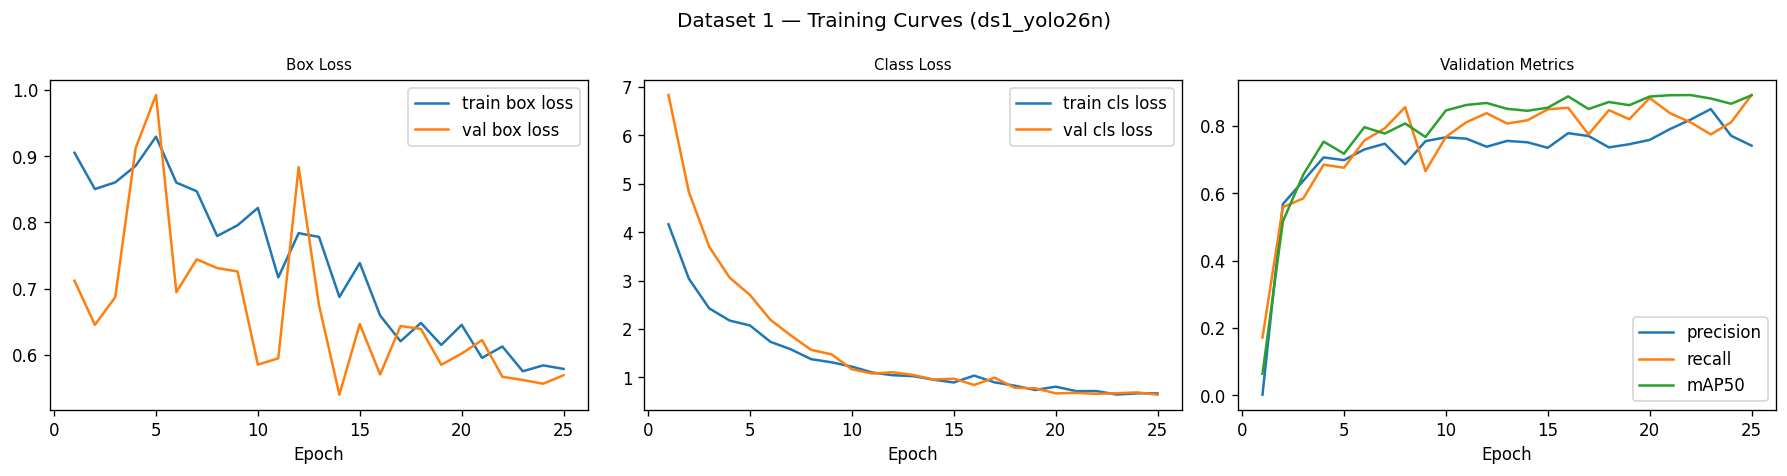

In [7]:
%matplotlib inline
history = pd.read_csv(RUN_DIR / 'results.csv')
history.columns = [c.strip() for c in history.columns]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Dataset 1 — Training Curves ({RUN_NAME})', fontsize=12)

axes[0].plot(history['epoch'], history['train/box_loss'], label='train box loss')
axes[0].plot(history['epoch'], history['val/box_loss'], label='val box loss')
axes[0].set_title('Box Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history['epoch'], history['train/cls_loss'], label='train cls loss')
axes[1].plot(history['epoch'], history['val/cls_loss'], label='val cls loss')
axes[1].set_title('Class Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history['epoch'], history['metrics/precision(B)'], label='precision')
axes[2].plot(history['epoch'], history['metrics/recall(B)'], label='recall')
axes[2].plot(history['epoch'], history['metrics/mAP50(B)'], label='mAP50')
axes[2].set_title('Validation Metrics')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Part 4 — Evaluation on the Held-Out Test Set

Everything so far used the **validation** split to monitor training. Now we evaluate the best checkpoint on the **test** split, which the model never saw during training.

In [8]:
best_model = YOLO(RUN_DIR / 'weights' / 'best.pt')

test_metrics = best_model.val(data=str(DATA_YAML), split='test', device=DEVICE)

print('=== Test Set Metrics ===')
print(f'Precision : {test_metrics.results_dict["metrics/precision(B)"]:.3f}')
print(f'Recall    : {test_metrics.results_dict["metrics/recall(B)"]:.3f}')
print(f'mAP@50    : {test_metrics.results_dict["metrics/mAP50(B)"]:.3f}')
print(f'mAP@50-95 : {test_metrics.results_dict["metrics/mAP50-95(B)"]:.3f}')

Ultralytics 8.4.84 🚀 Python-3.13.12 torch-2.6.0+cu124 CUDA:0 (NVIDIA T600 Laptop GPU, 3721MiB)


YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3225.1±1715.1 MB/s, size: 1442.9 KB)


val: Scanning /home/rios/projects/tutorial-MM/data/dataset1/fold_1/test/labels.cache... 53 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 53/53 14.8Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 25% ━━━───────── 1/4 6.7s/it 2.0s<20.1s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 1.1s/it 4.3s

                   all         53        160      0.799      0.868      0.868      0.773


Speed: 4.9ms preprocess, 15.7ms inference, 0.0ms loss, 0.3ms postprocess per image


Results saved to /home/rios/projects/tutorial-MM/runs/detect/val


=== Test Set Metrics ===
Precision : 0.799
Recall    : 0.868
mAP@50    : 0.868
mAP@50-95 : 0.773


### 4.1 Confusion Matrix and PR Curve

`model.val()` also saves diagnostic plots to its run directory. Let's display them.

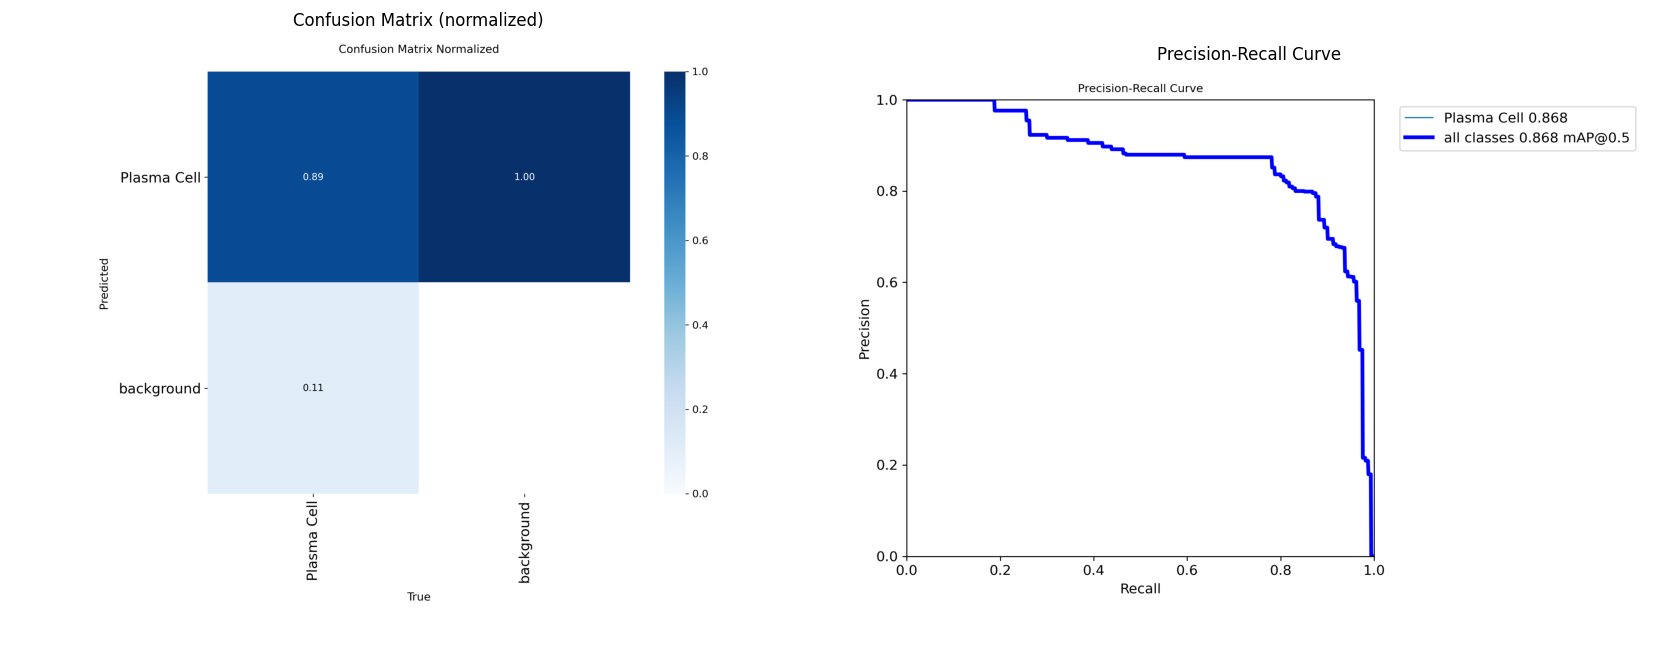

In [9]:
%matplotlib inline
val_run_dir = Path(test_metrics.save_dir)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, fname, title in zip(
    axes,
    ['confusion_matrix_normalized.png', 'BoxPR_curve.png'],
    ['Confusion Matrix (normalized)', 'Precision-Recall Curve'],
):
    img_path = val_run_dir / fname
    if img_path.exists():
        ax.imshow(plt.imread(img_path))
        ax.set_title(title, fontsize=10)
    else:
        ax.text(0.5, 0.5, f'{fname}\nnot found', ha='center', va='center')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## Part 5 — Visualizing Predictions vs. Ground Truth

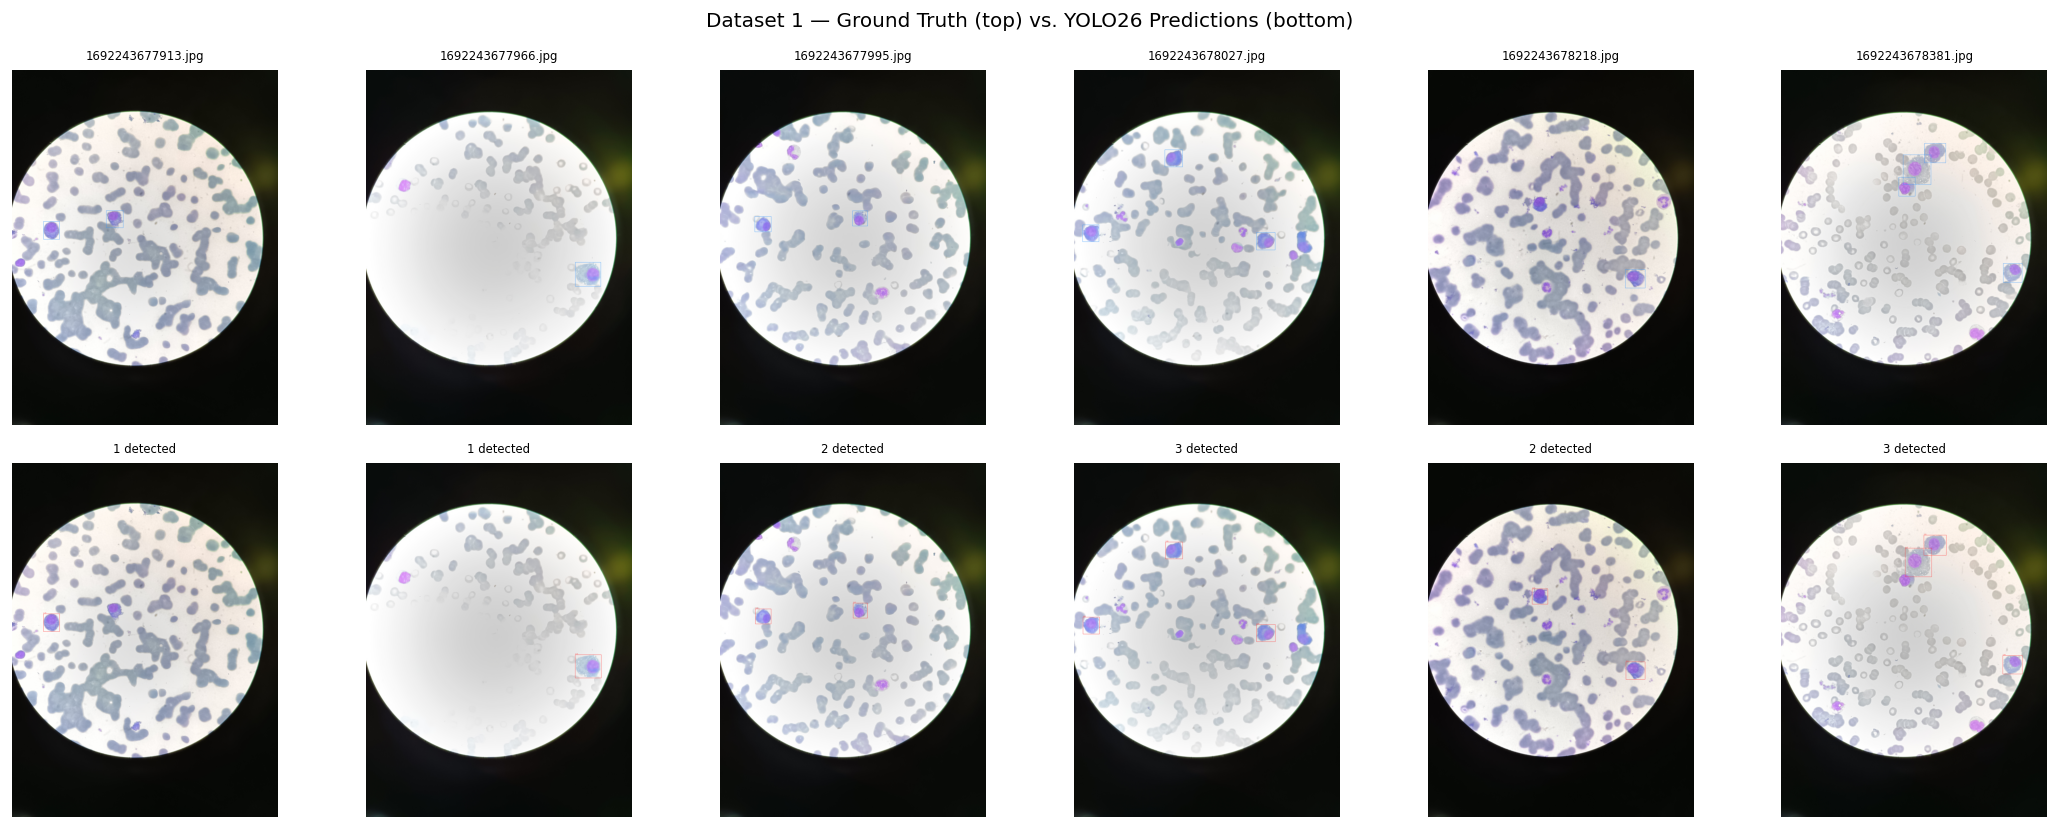

In [10]:
%matplotlib inline
def load_rgb(path):
    """Read an image and convert it to RGB."""
    img = cv2.imread(str(path))
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def draw_gt_boxes(img, label_path, color=(50, 150, 255)):
    """Draw ground-truth YOLO boxes on an image (numpy RGB)."""
    img_out = img.copy()
    H, W = img_out.shape[:2]
    if not label_path.exists():
        return img_out
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            cx, cy, bw, bh = map(float, parts[1:5])
            x1 = int((cx - bw / 2) * W)
            y1 = int((cy - bh / 2) * H)
            x2 = int((cx + bw / 2) * W)
            y2 = int((cy + bh / 2) * H)
            cv2.rectangle(img_out, (x1, y1), (x2, y2), color, 2)
    return img_out


def draw_pred_boxes(img, result, color=(255, 50, 50)):
    """Draw predicted boxes on an image (numpy RGB), labeled with confidence."""
    img_out = img.copy()
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        conf = float(box.conf[0])
        cv2.rectangle(img_out, (x1, y1), (x2, y2), color, 2)
        cv2.putText(img_out, f'{conf:.2f}', (x1, max(y1 - 5, 12)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1, cv2.LINE_AA)
    return img_out


test_images = sorted((FOLD_DIR / 'test' / 'images').glob('*.jpg'))
n = min(6, len(test_images))
predictions = best_model.predict(test_images[:n], device=DEVICE, verbose=False)

fig, axes = plt.subplots(2, n, figsize=(3 * n, 7))
fig.suptitle('Dataset 1 — Ground Truth (top) vs. YOLO26 Predictions (bottom)', fontsize=12)

for col, (img_path, result) in enumerate(zip(test_images[:n], predictions)):
    img = load_rgb(img_path)
    label_path = Path(str(img_path).replace('/images/', '/labels/')).with_suffix('.txt')

    gt_img = draw_gt_boxes(img, label_path)
    axes[0, col].imshow(gt_img)
    axes[0, col].set_title(img_path.name, fontsize=7)
    axes[0, col].axis('off')

    pred_img = draw_pred_boxes(img, result)
    axes[1, col].imshow(pred_img)
    axes[1, col].set_title(f'{len(result.boxes)} detected', fontsize=7)
    axes[1, col].axis('off')

plt.tight_layout()
plt.show()

---
## Summary

In this notebook you learned how to:

1. **Describe** a YOLO-format dataset with a `data.yaml` file
2. **Fine-tune** a pretrained YOLO26 nano model on plasma cell detection
3. **Read** training curves (losses, precision, recall, mAP)
4. **Evaluate** a trained model on a held-out test split
5. **Visualize** predictions against ground-truth annotations

**Ideas to extend this notebook:**
- Train on more folds and average metrics across the 10-fold cross-validation
- Try a larger model (`yolo26s`, `yolo26m`) or more epochs for higher accuracy
- Repeat the same pipeline on Dataset 2 (PCMMD), including the segmentation task

**References:**
- Andrade et al. (2024). *Multiple Myeloma Dataset*. Scientific Reports, 14, 11176. https://doi.org/10.1038/s41598-024-61420-9
- Ultralytics YOLO26. https://docs.ultralytics.com/